<a href="https://colab.research.google.com/github/martin-cacabelos/labo2025v/blob/main/src/workflows/610_WorkFlow_01_gerencial_julio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6 WorkFlow  Gerencial, futuro=JULIO

### 6.1 Objetivo

Presentar un workflow/pipeline completo al que los estudiantes deberán enriquecer

#### 6.2  Seteo del ambiente en Google Colab

Esta parte se debe correr con el runtime en Python3
<br>Ir al menu, Runtime -> Change Runtime Type -> Runtime type ->  **Python 3**

Conectar la virtual machine donde esta corriendo Google Colab con el  Google Drive, para poder tener persistencia de archivos

In [1]:
# primero establecer el Runtime de Python 3
from google.colab import drive
drive.mount('/content/.drive')

Mounted at /content/.drive


Para correr la siguiente celda es fundamental en Arranque en Frio haber copiado el archivo kaggle.json al Google Drive, en la carpeta indicada en el instructivo

<br>los siguientes comando estan en shell script de Linux
*   Crear las carpetas en el Google Drive
*   "instalar" el archivo kaggle.json desde el Google Drive a la virtual machine para que pueda ser utilizado por la libreria  kaggle de Python
*   Bajar el  **dataset_pequeno**  al  Google Drive  y tambien al disco local de la virtual machine que esta corriendo Google Colab
*   Bajar el **dataset_historico** al Google Drive y tambien al disco local de la virtual machine que esta corriendo Google Colab



In [2]:
%%shell

mkdir -p "/content/.drive/My Drive/labo1"
mkdir -p "/content/buckets"
ln -s "/content/.drive/My Drive/labo1" /content/buckets/b1

mkdir -p ~/.kaggle
cp /content/buckets/b1/kaggle/kaggle.json  ~/.kaggle
chmod 600 ~/.kaggle/kaggle.json


mkdir -p /content/buckets/b1/exp
mkdir -p /content/buckets/b1/datasets
mkdir -p /content/datasets


webfiles="https://storage.googleapis.com/open-courses/austral2025-af91/"
destino_local="/content/datasets"
destino_bucket="/content/buckets/b1/datasets"


archivo="dataset_pequeno.csv"

if ! test -f $destino_bucket/$archivo; then
  wget  $webfiles/$archivo  -O $destino_bucket/$archivo
fi


if ! test -f $destino_local/$pequeno; then
  cp  $destino_bucket/$archivo  $destino_local/$archivo
fi

#-------

archivo="gerencial_competencia_2025.csv.gz"

if ! test -f $destino_bucket/$archivo; then
  wget  $webfiles/$archivo  -O $destino_bucket/$archivo
fi


if ! test -f $destino_local/$pequeno; then
  cp  $destino_bucket/$archivo  $destino_local/$archivo
fi


## 6.3  Workflow

In [1]:
# ============================
# INICIALIZACION
# ============================

format(Sys.time(), "%a %b %d %X %Y")
rm(list=ls(all.names=TRUE))
gc(full=TRUE, verbose=FALSE)

if( !require("data.table")) install.packages("data.table")
if( !require("R.utils")) install.packages("R.utils")
if( !require("lightgbm")) install.packages("lightgbm")
if( !require("DiceKriging")) install.packages("DiceKriging")
if( !require("mlrMBO")) install.packages("mlrMBO")

library(data.table)
library(R.utils)
library(lightgbm)
library(DiceKriging)
library(mlrMBO)

PARAM <- list()
PARAM$semilla_primigenia <- 782611
PARAM$experimento <- 6310
PARAM$dataset <- "gerencial_competencia_2025.csv.gz"

# carpeta de trabajo (ajustar si hace falta)
setwd("/content/buckets/b1/exp")
experimento_folder <- paste0("WF", PARAM$experimento)
dir.create(experimento_folder, showWarnings=FALSE)
setwd(paste0("/content/buckets/b1/exp/", experimento_folder))

# ============================
# LECTURA DEL DATASET
# ============================

dataset <- fread(paste0("/content/datasets/", PARAM$dataset))

# ============================
# CATASTROPHE ANALYSIS
# ============================

dataset[ foto_mes==202006, internet:=NA]
dataset[ foto_mes==202006, mrentabilidad:=NA]
dataset[ foto_mes==202006, mrentabilidad_annual:=NA]
dataset[ foto_mes==202006, mcomisiones:=NA]
dataset[ foto_mes==202006, mactivos_margen:=NA]
dataset[ foto_mes==202006, mpasivos_margen:=NA]
dataset[ foto_mes==202006, mcuentas_saldo:=NA]
dataset[ foto_mes==202006, ctarjeta_visa_transacciones:=NA]
dataset[ foto_mes==202006, mtarjeta_visa_consumo:=NA]
dataset[ foto_mes==202006, mtarjeta_master_consumo:=NA]
dataset[ foto_mes==202006, ccallcenter_transacciones:=NA]
dataset[ foto_mes==202006, chomebanking_transacciones:=NA]

# ============================
# FE INTRA-MES
# ============================

atributos_presentes <- function( patributos )
{
  atributos <- unique( patributos )
  comun <- intersect( atributos, colnames(dataset) )
  return(  length( atributos ) == length( comun ) )
}

if( atributos_presentes( c("foto_mes") ))
  dataset[, kmes := foto_mes %% 100]

if( atributos_presentes( c("mpayroll", "cliente_edad") ))
  dataset[, mpayroll_sobre_edad := mpayroll / cliente_edad]

# ============================
# FE HISTORICO
# ============================

cols_lagueables <- setdiff(
  colnames(dataset),
  c("numero_de_cliente", "foto_mes", "clase_ternaria")
)

dataset[,
  paste0(cols_lagueables, "_lag1") := shift(.SD, 1, NA, "lag"),
  by = numero_de_cliente,
  .SDcols = cols_lagueables
]

dataset[,
  paste0(cols_lagueables, "_lag2") := shift(.SD, 2, NA, "lag"),
  by = numero_de_cliente,
  .SDcols = cols_lagueables
]

for (vcol in cols_lagueables)
{
  dataset[, paste0(vcol, "_delta1") := get(vcol) - get(paste0(vcol, "_lag1"))]
  dataset[, paste0(vcol, "_delta2") := get(vcol) - get(paste0(vcol, "_lag2"))]
}

# ============================
# CALCULO CHURN MENSUAL Y P75
# ============================

tb_churn_mes <- dataset[, .(
  n = .N,
  bajas = sum(clase_ternaria %in% c("BAJA+1","BAJA+2"))
), by = foto_mes]

tb_churn_mes[, churn := bajas / n]

p75 <- quantile(tb_churn_mes$churn, 0.75)
meses_bajos <- tb_churn_mes[churn < p75,  foto_mes]
meses_altos <- tb_churn_mes[churn > p75,  foto_mes]

cat("\nChurn por mes:\n"); print(tb_churn_mes)
cat("\nPercentil 75 de churn:", p75, "\n")
cat("Meses bajos  (churn < p75):", paste(meses_bajos, collapse=", "), "\n")
cat("Meses altos (churn > p75):", paste(meses_altos, collapse=", "), "\n")

# ============================
# TRAINING STRATEGY BASE
# ============================

PARAM$trainingstrategy <- list()
PARAM$trainingstrategy$validate     <- c(202105)
PARAM$trainingstrategy$training_pct <- 1.0
PARAM$trainingstrategy$future       <- c(202107)

# meses base de entrenamiento y final_train (baseline)
base_train <- c(
  202104, 202103, 202102, 202101,
  202012, 202011, 202010, 202009, 202008, 202007,
  202006, 202005
)

base_finaltrain <- c(
  202105, 202104, 202103, 202102, 202101,
  202012, 202011, 202010, 202009, 202008, 202007,
  202006, 202005
)

PARAM$trainingstrategy$positivos <- c("BAJA+1", "BAJA+2")

# ============================
# PARAMETROS LIGHTGBM Y BO
# ============================

PARAM$lgbm <- list()
PARAM$lgbm$param_fijos <- list(
  objective= "binary",
  metric= "auc",
  first_metric_only= TRUE,
  boost_from_average= TRUE,
  feature_pre_filter= FALSE,
  verbosity= -100,
  force_row_wise= TRUE,
  seed= PARAM$semilla_primigenia,
  max_bin= 31,
  learning_rate= 0.03,
  feature_fraction= 0.5,
  num_iterations= 2048,
  early_stopping_rounds= 200
)

PARAM$hipeparametertuning <- list()
PARAM$hipeparametertuning$num_interations <- 10
PARAM$hipeparametertuning$hs <- makeParamSet(
  makeIntegerParam("num_leaves", lower = 2L, upper = 256L),
  makeIntegerParam("min_data_in_leaf", lower = 2L, upper = 8192L)
)

configureMlr(show.learner.output = FALSE)

# ============================
# FUNCION: ESTIMAR AUC PARA BO
# ============================

EstimarGanancia_AUC_lightgbm <- function(x) {

  param_completo <- modifyList(PARAM$lgbm$param_fijos, x)

  modelo_train <- lgb.train(
    data= dtrain,
    valids= list(valid = dvalidate),
    eval= "auc",
    param= param_completo,
    verbose= -100
  )

  AUC <- modelo_train$record_evals$valid$auc$eval[[modelo_train$best_iter]]

  attr(AUC, "extras") <- list("num_iterations"= modelo_train$best_iter)

  rm(modelo_train)
  gc(full= TRUE, verbose= FALSE)

  message(format(Sys.time(), "%a %b %d %X %Y"), " AUC ", AUC)

  return(AUC)
}

# ============================
# FUNCION GENERAL DE EXPERIMENTO
# ============================

correr_experimento <- function(nombre_exp, meses_excluir) {

  cat("\n=============================\n")
  cat("Experimento:", nombre_exp, "\n")
  cat("Excluir meses:", ifelse(length(meses_excluir)==0,"(ninguno)", paste(meses_excluir, collapse=", ")), "\n")
  cat("=============================\n")

  # defino meses de training y final_train
  PARAM$trainingstrategy$training    <<- setdiff(base_train,      meses_excluir)
  PARAM$trainingstrategy$final_train <<- setdiff(base_finaltrain, meses_excluir)

  cat("Training meses:    ", paste(PARAM$trainingstrategy$training, collapse=", "), "\n")
  cat("Final_train meses: ", paste(PARAM$trainingstrategy$final_train, collapse=", "), "\n")

  # clase01
  dataset[, clase01 := ifelse( clase_ternaria %in% PARAM$trainingstrategy$positivos, 1, 0 )]

  campos_buenos <<- setdiff(colnames(dataset), c("clase_ternaria","clase01","azar"))

  # azar para undersampling (aunque training_pct=1)
  set.seed(PARAM$semilla_primigenia, kind = "L'Ecuyer-CMRG")
  dataset[, azar := runif(.N)]

  dataset[, fold_train :=  foto_mes %in%  PARAM$trainingstrategy$training &
      (clase_ternaria %in% c("BAJA+1", "BAJA+2") |
       azar < PARAM$trainingstrategy$training_pct ) ]

  # datasets de entrenamiento y validacion
  dtrain <<- lgb.Dataset(
    data= data.matrix(dataset[fold_train == TRUE, campos_buenos, with = FALSE]),
    label= dataset[fold_train == TRUE, clase01],
    free_raw_data= TRUE
  )

  dvalidate <<- lgb.Dataset(
    data= data.matrix(dataset[foto_mes %in% PARAM$trainingstrategy$validate, campos_buenos, with = FALSE]),
    label= dataset[foto_mes %in% PARAM$trainingstrategy$validate, clase01],
    free_raw_data= TRUE
  )

  # BAYESIANA
  obj.fun <- makeSingleObjectiveFunction(
      fn= EstimarGanancia_AUC_lightgbm,
      minimize= FALSE,
      noisy= FALSE,
      par.set= PARAM$hipeparametertuning$hs,
      has.simple.signature= FALSE
  )

  ctrl <- makeMBOControl(
      save.on.disk.at.time= 600,
      save.file.path= "HT.RDATA"
  )

  ctrl <- setMBOControlTermination(
      ctrl,
      iters= PARAM$hipeparametertuning$num_interations
  )

  ctrl <- setMBOControlInfill(ctrl, crit = makeMBOInfillCritEI())

  surr.km <- makeLearner(
      "regr.km",
      predict.type= "se",
      covtype= "matern3_2",
      control= list(trace = TRUE)
  )

  if (file.exists("HT.RDATA")) file.remove("HT.RDATA")

  bayesiana_salida <- mbo(obj.fun, learner= surr.km, control= ctrl)

  tb_bayesiana <- as.data.table(bayesiana_salida$opt.path)
  setorder(tb_bayesiana, -y)

  mejores_hiper <- tb_bayesiana[1,
    .(num_leaves, min_data_in_leaf)
  ]

  cat("Mejores hiperparámetros encontrados:\n")
  print(mejores_hiper)

  # armo parametros finales
  fijos <- PARAM$lgbm$param_fijos
  fijos$num_iterations <- NULL
  fijos$early_stopping_rounds <- NULL

  param_final <- c(fijos, as.list(mejores_hiper))

  # FINAL TRAINING
  dataset[, fold_final_train := foto_mes %in% PARAM$trainingstrategy$final_train ]

  dfinal_train <- lgb.Dataset(
    data= data.matrix(dataset[fold_final_train == TRUE, campos_buenos, with= FALSE]),
    label= dataset[fold_final_train == TRUE, clase01],
    free_raw_data= TRUE
  )

  final_model <- lgb.train(
    data= dfinal_train,
    param= param_final,
    verbose= -100
  )

  # SCORING SOBRE FUTURO
  dfuture <- dataset[ foto_mes %in% PARAM$trainingstrategy$future ]

  prediccion <- predict(
    final_model,
    data.matrix(dfuture[, campos_buenos, with= FALSE])
  )

  tb_prediccion <- dfuture[, .(numero_de_cliente)]
  tb_prediccion[, prob := prediccion]
  tb_prediccion[, clase_ternaria := dfuture$clase_ternaria ]

  tb_prediccion[, ganancia := -3000.0 ]
  tb_prediccion[clase_ternaria=="BAJA+2", ganancia := 117000.0 ]

  setorder( tb_prediccion, -prob )
  tb_prediccion[, gan_acum := cumsum(ganancia)]

  tb_prediccion[, gan_suavizada := frollmean(
      x= gan_acum,
      n= 400,
      align= "center",
      na.rm= TRUE,
      hasNA= TRUE
  )]

  ganancia_suavizada_max <- max( tb_prediccion$gan_suavizada, na.rm=TRUE )
  envios <- which.max( tb_prediccion$gan_suavizada)

  cat("Ganancia suavizada max:", ganancia_suavizada_max, " | Envios:", envios, "\n")

  return( list(
    experimento = nombre_exp,
    ganancia = ganancia_suavizada_max,
    envios = envios
  ))
}

# ============================
# CORRER TODOS LOS EXPERIMENTOS
# ============================

resultados <- list()

# 0) BASELINE (sin excluir nada)
resultados[[length(resultados)+1]] <- correr_experimento("baseline", meses_excluir = integer(0))

# 1) EXP1: sin 202005–202006
resultados[[length(resultados)+1]] <- correr_experimento("exp1_sin_202005_202006", meses_excluir = c(202005, 202006))

# 2) EXP2: sin 202005–202010
resultados[[length(resultados)+1]] <- correr_experimento("exp2_sin_202005_202010",
                                                         meses_excluir = c(202005,202006,202007,202008,202009,202010))

# 3) EXP3: sin meses_bajos (churn < p75)
resultados[[length(resultados)+1]] <- correr_experimento("exp3_sin_meses_bajos", meses_excluir = meses_bajos)

# 4) EXP4: sin meses_altos (churn > p75)
resultados[[length(resultados)+1]] <- correr_experimento("exp4_sin_meses_altos", meses_excluir = meses_altos)

# ============================
# TABLA FINAL
# ============================

res_experimentos <- rbindlist(resultados)
cat("\n==== RESULTADOS FINALES ====\n")
print(res_experimentos)



[1] "Sun Nov 23 03:49:41 PM 2025"

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,663523,35.5,1454497,77.7,1454497,77.7
Vcells,1232816,9.5,8388608,64.0,1975136,15.1


Loading required package: data.table

Loading required package: R.utils

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘R.utils’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘R.oo’, ‘R.methodsS3’


Loading required package: lightgbm

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘lightgbm’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: DiceKriging

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘DiceKriging’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: mlrMBO

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, log


Churn por mes:
    foto_mes     n bajas       churn
       <int> <int> <int>       <num>
 1:   202005 15082   116 0.007691288
 2:   202006 15323   126 0.008222933
 3:   202007 15522   108 0.006957866
 4:   202008 15695    89 0.005670596
 5:   202009 15854   105 0.006622934
 6:   202010 15996   107 0.006689172
 7:   202011 16113   109 0.006764724
 8:   202012 16172   118 0.007296562
 9:   202101 16230   144 0.008872458
10:   202102 16289   186 0.011418749
11:   202103 16365   170 0.010388023
12:   202104 16394   182 0.011101623
13:   202105 16469   183 0.011111786
14:   202106 16507   196 0.011873751
15:   202107 16551   265 0.016011117
16:   202108 16553   142 0.008578505
17:   202109 16551     0 0.000000000

Percentil 75 de churn: 0.01110162 
Meses bajos  (churn < p75): 202005, 202006, 202007, 202008, 202009, 202010, 202011, 202012, 202101, 202103, 202108, 202109 
Meses altos (churn > p75): 202102, 202105, 202106, 202107 

Experimento: baseline 
Excluir meses: (ninguno) 
Training mes

Computing y column(s) for design. Not provided.

Sun Nov 23 04:06:55 PM 2025 AUC 0.918889736667452

Sun Nov 23 04:09:06 PM 2025 AUC 0.922998666594192

Sun Nov 23 04:13:35 PM 2025 AUC 0.93323206965116

Sun Nov 23 04:16:30 PM 2025 AUC 0.918466630294953

Sun Nov 23 04:20:15 PM 2025 AUC 0.932771048116019

Sun Nov 23 04:22:21 PM 2025 AUC 0.929360361140247

Sun Nov 23 04:25:14 PM 2025 AUC 0.922066557551526

Sun Nov 23 04:31:01 PM 2025 AUC 0.928394027791479

[mbo] 0: num_leaves=11; min_data_in_leaf=6596 : y = 0.919 : 212.9 secs : initdesign

[mbo] 0: num_leaves=203; min_data_in_leaf=4066 : y = 0.923 : 130.5 secs : initdesign

[mbo] 0: num_leaves=128; min_data_in_leaf=2226 : y = 0.933 : 268.7 secs : initdesign

[mbo] 0: num_leaves=145; min_data_in_leaf=7888 : y = 0.918 : 175.4 secs : initdesign

[mbo] 0: num_leaves=189; min_data_in_leaf=1295 : y = 0.933 : 224.7 secs : initdesign

[mbo] 0: num_leaves=81; min_data_in_leaf=278 : y = 0.929 : 126.7 secs : initdesign

[mbo] 0: num_leaves=251; min_da

...

Mejores hiperparámetros encontrados:
   num_leaves min_data_in_leaf
        <int>            <int>
1:        232                2
Ganancia suavizada max: 5912400  | Envios: 1680 

Experimento: exp3_sin_meses_bajos 
Excluir meses: 202005, 202006, 202007, 202008, 202009, 202010, 202011, 202012, 202101, 202103, 202108, 202109 
Training meses:     202104, 202102 
Final_train meses:  202105, 202104, 202102 


Computing y column(s) for design. Not provided.

Sun Nov 23 06:46:05 PM 2025 AUC 0.901600758034827

Sun Nov 23 06:46:24 PM 2025 AUC 0.906549525590722

Sun Nov 23 06:46:55 PM 2025 AUC 0.917958634222025

Sun Nov 23 06:47:24 PM 2025 AUC 0.895907779587416

Sun Nov 23 06:48:09 PM 2025 AUC 0.922106485908645

Sun Nov 23 06:48:38 PM 2025 AUC 0.932600933182746

Sun Nov 23 06:48:53 PM 2025 AUC 0.904841330077327

Sun Nov 23 06:49:06 PM 2025 AUC 0.907154826063353

[mbo] 0: num_leaves=11; min_data_in_leaf=6596 : y = 0.902 : 26.4 secs : initdesign

[mbo] 0: num_leaves=203; min_data_in_leaf=4066 : y = 0.907 : 18.9 secs : initdesign

[mbo] 0: num_leaves=128; min_data_in_leaf=2226 : y = 0.918 : 30.7 secs : initdesign

[mbo] 0: num_leaves=145; min_data_in_leaf=7888 : y = 0.896 : 29.7 secs : initdesign

[mbo] 0: num_leaves=189; min_data_in_leaf=1295 : y = 0.922 : 44.4 secs : initdesign

[mbo] 0: num_leaves=81; min_data_in_leaf=278 : y = 0.933 : 29.0 secs : initdesign

[mbo] 0: num_leaves=251; min_data_in

Mejores hiperparámetros encontrados:
   num_leaves min_data_in_leaf
        <int>            <int>
1:        178                2
Ganancia suavizada max: 5653200  | Envios: 1933 

Experimento: exp4_sin_meses_altos 
Excluir meses: 202102, 202105, 202106, 202107 
Training meses:     202104, 202103, 202101, 202012, 202011, 202010, 202009, 202008, 202007, 202006, 202005 
Final_train meses:  202104, 202103, 202101, 202012, 202011, 202010, 202009, 202008, 202007, 202006, 202005 


Computing y column(s) for design. Not provided.

Sun Nov 23 06:57:37 PM 2025 AUC 0.920947892487362

Sun Nov 23 07:02:48 PM 2025 AUC 0.927623980904179

Sun Nov 23 07:08:13 PM 2025 AUC 0.935797550479174

Sun Nov 23 07:10:50 PM 2025 AUC 0.9230251736548

Sun Nov 23 07:13:44 PM 2025 AUC 0.934081302187873

Sun Nov 23 07:18:09 PM 2025 AUC 0.937295031637351

Sun Nov 23 07:23:21 PM 2025 AUC 0.928595011706726

Sun Nov 23 07:26:04 PM 2025 AUC 0.925920818376976

[mbo] 0: num_leaves=11; min_data_in_leaf=6596 : y = 0.921 : 214.9 secs : initdesign

[mbo] 0: num_leaves=203; min_data_in_leaf=4066 : y = 0.928 : 311.4 secs : initdesign

[mbo] 0: num_leaves=128; min_data_in_leaf=2226 : y = 0.936 : 324.7 secs : initdesign

[mbo] 0: num_leaves=145; min_data_in_leaf=7888 : y = 0.923 : 156.5 secs : initdesign

[mbo] 0: num_leaves=189; min_data_in_leaf=1295 : y = 0.934 : 174.5 secs : initdesign

[mbo] 0: num_leaves=81; min_data_in_leaf=278 : y = 0.937 : 264.9 secs : initdesign

[mbo] 0: num_leaves=251; min_dat

Mejores hiperparámetros encontrados:
   num_leaves min_data_in_leaf
        <int>            <int>
1:        188                2
Ganancia suavizada max: 6077400  | Envios: 1309 

==== RESULTADOS FINALES ====
              experimento ganancia envios
                   <char>    <num>  <int>
1:               baseline  6338400   1602
2: exp1_sin_202005_202006  5949900   1291
3: exp2_sin_202005_202010  5912400   1680
4:   exp3_sin_meses_bajos  5653200   1933
5:   exp4_sin_meses_altos  6077400   1309


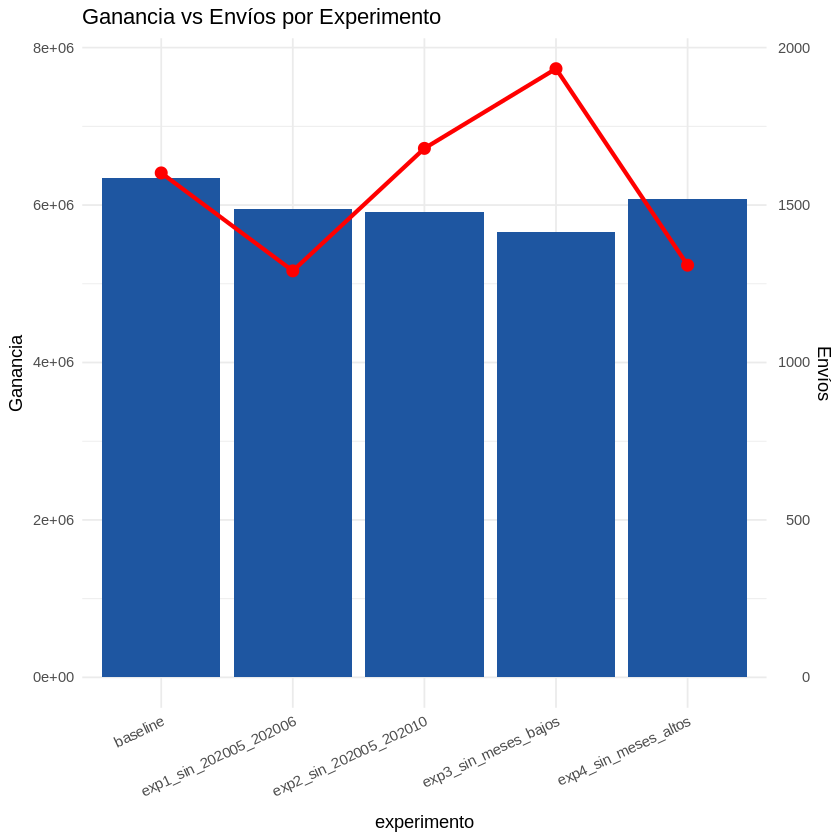

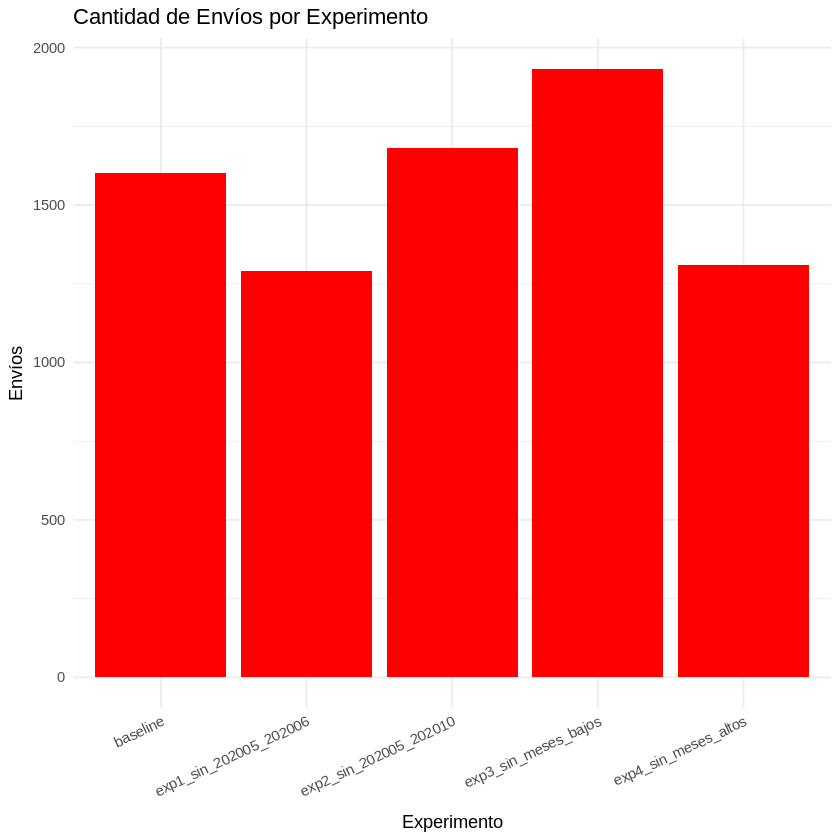

In [3]:
library(ggplot2)
library(data.table)
library(scales)

res_experimentos <- data.table(
  experimento = c("baseline",
                  "exp1_sin_202005_202006",
                  "exp2_sin_202005_202010",
                  "exp3_sin_meses_bajos",
                  "exp4_sin_meses_altos"),
  ganancia = c(6338400, 5949900, 5912400, 5653200, 6077400),
  envios   = c(1602, 1291, 1680, 1933, 1309)
)

### A) Barras de Ganancia + barra secundaria de Envíos
ggplot(res_experimentos, aes(x = experimento)) +
  geom_col(aes(y = ganancia), fill="#1E56A1") +
  geom_line(aes(y = envios * 4000), group=1, color="red", size=1.2) +
  geom_point(aes(y = envios * 4000), color="red", size=3) +
  scale_y_continuous(
    name="Ganancia",
    sec.axis = sec_axis(~./4000, name="Envíos")
  ) +
  labs(title="Ganancia vs Envíos por Experimento") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle=25, hjust=1))

### B) Envíos solos
ggplot(res_experimentos, aes(x = experimento, y = envios)) +
  geom_col(fill="red") +
  labs(title="Cantidad de Envíos por Experimento",
       x="Experimento", y="Envíos") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle=25, hjust=1))


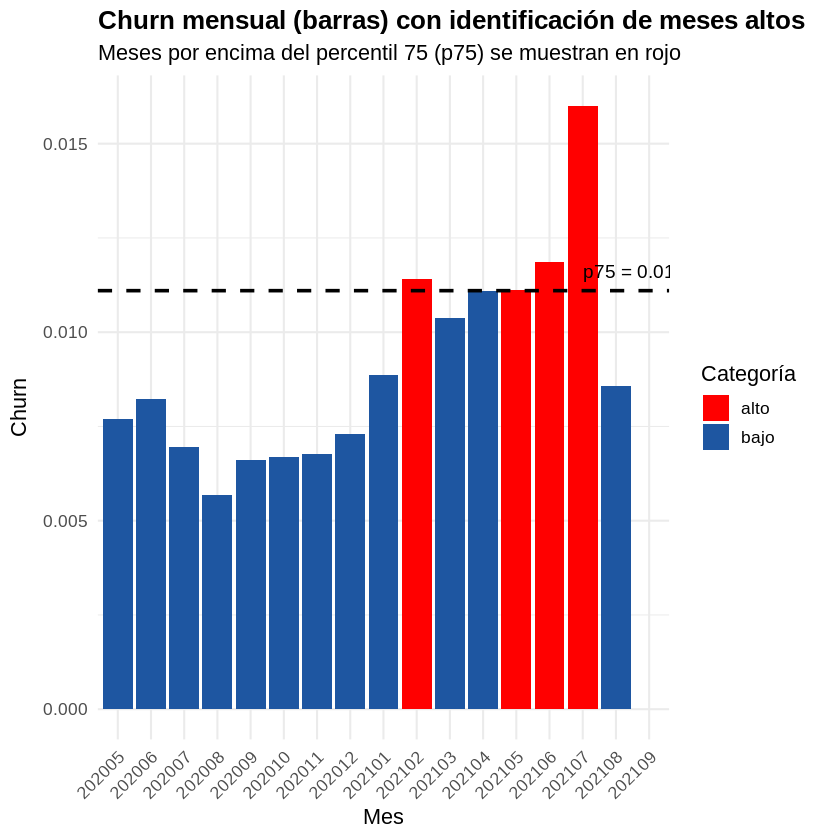

In [2]:
library(data.table)
library(ggplot2)

# ------------------------------
# 1. RECONSTRUCCIÓN DE LA TABLA
# ------------------------------
tb_churn_mes <- data.table(
  foto_mes = c(
    202005, 202006, 202007, 202008, 202009, 202010,
    202011, 202012, 202101, 202102, 202103, 202104,
    202105, 202106, 202107, 202108, 202109
  ),
  n = c(
    15082, 15323, 15522, 15695, 15854, 15996,
    16113, 16172, 16230, 16289, 16365, 16394,
    16469, 16507, 16551, 16553, 16551
  ),
  bajas = c(
    116, 126, 108, 89, 105, 107,
    109, 118, 144, 186, 170, 182,
    183, 196, 265, 142, 0
  )
)

# ------------------------------
# 2. CÁLCULO DEL CHURN
# ------------------------------
tb_churn_mes[, churn := bajas / n]

# ------------------------------
# 3. CÁLCULO DEL p75
# ------------------------------
p75 <- quantile(tb_churn_mes$churn, probs = 0.75)

# ------------------------------
# 4. CLASIFICACIÓN BAJO / ALTO
# ------------------------------
tb_churn_mes[, categoria := ifelse(churn > p75, "alto", "bajo")]

# ------------------------------
# 5. GRÁFICO FINAL
# ------------------------------

ggplot(tb_churn_mes, aes(x = factor(foto_mes), y = churn, fill = categoria)) +
  geom_col() +
  scale_fill_manual(values = c("bajo" = "#1E56A1", "alto" = "red")) +
  geom_hline(yintercept = p75,
             color = "black",
             linetype = "dashed",
             size = 1) +
  annotate("text",
           x = length(tb_churn_mes$foto_mes) - 2,
           y = p75 + 0.0005,
           label = paste0("p75 = ", round(p75, 4)),
           color = "black",
           size = 4,
           hjust = 0) +
  labs(
    title = "Churn mensual (barras) con identificación de meses altos",
    subtitle = "Meses por encima del percentil 75 (p75) se muestran en rojo",
    x = "Mes",
    y = "Churn",
    fill = "Categoría"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(face = "bold")
  )


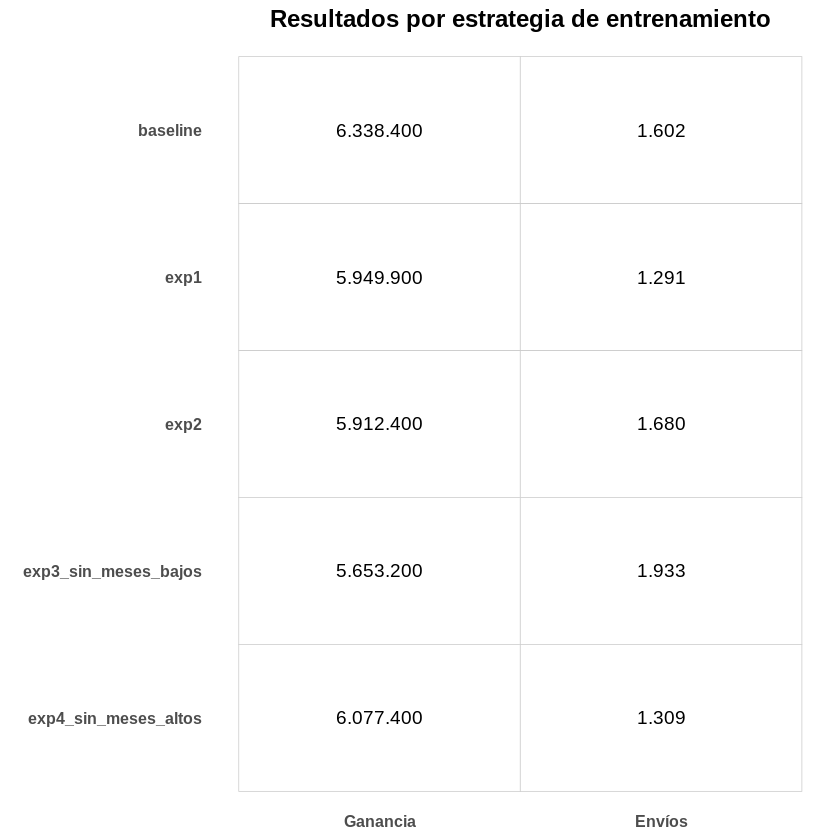

In [5]:
library(data.table)
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)

# 1) Datos de la diapo 5
res_experimentos <- data.table(
  experimento = c(
    "baseline",
    "exp1",
    "exp2",
    "exp3_sin_meses_bajos",
    "exp4_sin_meses_altos"
  ),
  ganancia = c(6338400, 5949900, 5912400, 5653200, 6077400),
  envios   = c(1602, 1291, 1680, 1933, 1309)
)

# 2) Preparo labels lindos (con separador de miles)
res_tabla <- res_experimentos %>%
  mutate(
    ganancia = comma(ganancia, big.mark = ".", decimal.mark = ","),
    envios   = format(envios, big.mark = ".", decimal.mark = ",")
  )

# 3) Paso a formato largo para armar "tabla" con ggplot
res_long <- res_tabla %>%
  pivot_longer(
    cols = c("ganancia", "envios"),
    names_to = "metrica",
    values_to = "valor"
  )

# 4) Orden de filas (de arriba hacia abajo en la tabla)
res_long$experimento <- factor(
  res_long$experimento,
  levels = rev(res_experimentos$experimento)
)

# 5) Renombro columnas para que queden prolijas en la tabla
res_long$metrica <- factor(
  res_long$metrica,
  levels = c("ganancia", "envios"),
  labels = c("Ganancia", "Envíos")
)

# 6) Tabla estilo ggplot
p_tabla <- ggplot(res_long, aes(x = metrica, y = experimento)) +
  geom_tile(fill = "white", color = "grey80") +
  geom_text(aes(label = valor), size = 4) +
  # Encabezados de columnas
  labs(
    title    = "Resultados por estrategia de entrenamiento",
    x        = NULL,
    y        = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold"),
    plot.title  = element_text(face = "bold", hjust = 0.5)
  )

# Mostrar en pantalla
p_tabla

# 7) (Opcional) Exportar como PNG para pegar en la diapo
ggsave("diapo5_tabla_resultados.png", p_tabla, width = 8, height = 4, dpi = 300)
